In [3]:
pip install pandas numpy scikit-learn nltk spacy matplotlib streamlit PyPDF2

Note: you may need to restart the kernel to use updated packages.


In [4]:
# downloading en_core_web_sm in spaCy
!python -m spacy download en_core_web_sm

     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.0/12.8 MB ? eta -:--:--
     ---------------------------------------- 0.1/12.8 MB 1.3 MB/s eta 0:00:10
     - -------------------------------------- 0.6/12.8 MB 4.6 MB/s eta 0:00:03
     ---- ----------------------------------- 1.3/12.8 MB 7.7 MB/s eta 0:00:02
     ------ --------------------------------- 2.0/12.8 MB 9.3 MB/s eta 0:00:02
     -------- ------------------------------- 2.8/12.8 MB 10.5 MB/s eta 0:00:01
     ----------- ---------------------------- 3.6/12.8 MB 11.5 MB/s eta 0:00:01
     ------------- -------------------------- 4.3/12.8 MB 12.0 MB/s eta 0:00:01
     --------------- ------------------------ 5.0/12.8 MB 12.2 MB/s eta 0:00:01
     ----------------- ---------------------- 5.5/12.8 MB 12.1 MB/s eta 0:00:01
     ------------------ --------------------- 6.1/12.8 MB 12.1 MB/s eta 0:00:01
     -------------------- ------------------- 6.6/12.8 MB 12

In [59]:
# all importation of library
# Data Handling
import pandas as pd
import numpy as np

# NLP Libraries
import nltk
import spacy
import re
import string

# Machine Learning
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# PDF Processing
import PyPDF2
import os

# Visualization
import matplotlib.pyplot as plt

# Streamlit (app)
import streamlit as st

# Ignore warnings
import warnings
warnings.filterwarnings("ignore")

In [60]:
# checking if stopwords and punkt are upto date 
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\dhava\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\dhava\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [61]:
nlp = spacy.load("en_core_web_sm")

print("spaCy loaded successfully!")

spaCy loaded successfully!


In [62]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

print(f"Total stopwords loaded: {len(stop_words)}")

Total stopwords loaded: 198


In [63]:
def extract_text_from_pdf(pdf_path):
    
    text = ""

    try:
        with open(pdf_path, "rb") as file:
            
            pdf_reader = PyPDF2.PdfReader(file)

            for page in pdf_reader.pages:
                
                page_text = page.extract_text()

                if page_text:
                    text += page_text

        return text

    except Exception as e:
        
        print(f"Error reading {pdf_path}")
        print(e)

        return ""

In [64]:
resume_folder = r"D:\AI_ATS_Resume_Screening_System\resume\test\Resumes"

In [65]:
print("Folder Exists:", os.path.exists(resume_folder))

print("\nFiles Found:\n")

for file in os.listdir(resume_folder):
    print(file)

Folder Exists: True

Files Found:

Abiral_Pandey_Fullstack_Java.pdf
Anudeep N_Sr Java Developer.pdf
Ashwini J2EE Developer.pdf
Bapuji Hadoop developer.pdf
CHETAN_Sr Java Developer.pdf
Drakshajavauidev.pdf
Gautami Bulusu Mobile Testing 3.pdf
Harika_java.pdf
HARI_SrJava Developer.pdf
Krishna_SrJava.pdf
madhuri_java.pdf
mahesh_Java.pdf
Mani_Hadoop.pdf
Murali_Project Manager QA.pdf
Niteesh Java Developer.pdf
Pavan Kumar Full Stack Java Developer.pdf
Rao_Java.pdf
RaviBurra_Certified PM_DevOps.pdf
Sai Srinivas_Sr_Java_Developer.pdf
Sharath Java.pdf
Shiva G-Java Resume.pdf
Sougandh_Java Fullstack Developer.pdf
Sumanth Manne Java Developer.pdf
Sundar_Java_8 Years.pdf
Tarun_Developer.pdf
Venkata_SrPHP_Developer.pdf
vikas java.pdf
Vishnu Java dev.pdf


In [66]:
resume_texts = {}

for file_name in os.listdir(resume_folder):

    if file_name.lower().endswith(".pdf"):

        file_path = os.path.join(resume_folder, file_name)

        text = extract_text_from_pdf(file_path)

        resume_texts[file_name] = text

print(f"\nTotal Resumes Loaded: {len(resume_texts)}")


Total Resumes Loaded: 28


In [67]:
list(resume_texts.keys())[:10]


['Abiral_Pandey_Fullstack_Java.pdf',
 'Anudeep N_Sr Java Developer.pdf',
 'Ashwini J2EE Developer.pdf',
 'Bapuji Hadoop developer.pdf',
 'CHETAN_Sr Java Developer.pdf',
 'Drakshajavauidev.pdf',
 'Gautami Bulusu Mobile Testing 3.pdf',
 'Harika_java.pdf',
 'HARI_SrJava Developer.pdf',
 'Krishna_SrJava.pdf']

In [68]:
# 
first_resume = list(resume_texts.keys())[0]

print("Resume Name:")
print(first_resume)

print("\nResume Content Preview:\n")

print(resume_texts[first_resume][:3000])

Resume Name:
Abiral_Pandey_Fullstack_Java.pdf

Resume Content Preview:

Name: Abiral Pandey
Email: abiral.pandey88@gmail.com
Phone: 940-242-3303
Current Location: Woonsocket, Rhode Island
Visa Status: US Citizen
SUMMARY:
Dynamic individual with 6 years of software development experience in design, development,
deployment, maintenance, production and support of web - based and Client-Server business
applications using OOP and Java/J2EE technologies.
Exposure to all phases of Software Development Life Cycle(SDLC) using Agile, RUP, Waterfall.
Designed and developed web UI screen using Angular-JS.
Developed AngularJS Controllers, Services, filters and directives for various modules in the application.
Knowledge on ETL tools like Kettle Pentaho and Microsoft SSIS tools.
Created custom directives, decorators and services using AngularJS to interface with both RESTful
and legacy network services also DOM applications.
Experience with MVC frameworks like Struts, SPRING and ORM tools like Hiber

In [69]:
resume_df = pd.DataFrame({

    "resume_name": resume_texts.keys(),
    "resume_text": resume_texts.values()

})

resume_df.head()

,resume_name,resume_text
0,Abiral_Pandey_Fullstack_Java.pdf,Name: Abiral Pandey\nEmail: abiral.pandey88@gm...
1,Anudeep N_Sr Java Developer.pdf,Anudeep\nSr Java Programmer\nanudeepreddynalla...
2,Ashwini J2EE Developer.pdf,Ashwini C\n©732-352-1613\nashwinicha8@gmail.co...
3,Bapuji Hadoop developer.pdf,Bapuji\nSr. Hadoop Developer\nPhone: +1(224)-7...
4,CHETAN_Sr Java Developer.pdf,CHETAN BABU\nMobile: 405-896-0512\nEmail: boor...


In [75]:
# converting resume_text to text_length
resume_df["text_length"] = resume_df["resume_text"].apply(len)

resume_df[["resume_name", "text_length"]].head()

,resume_name,text_length
0,Abiral_Pandey_Fullstack_Java.pdf,13972
1,Anudeep N_Sr Java Developer.pdf,12049
2,Ashwini J2EE Developer.pdf,19615
3,Bapuji Hadoop developer.pdf,14384
4,CHETAN_Sr Java Developer.pdf,13237


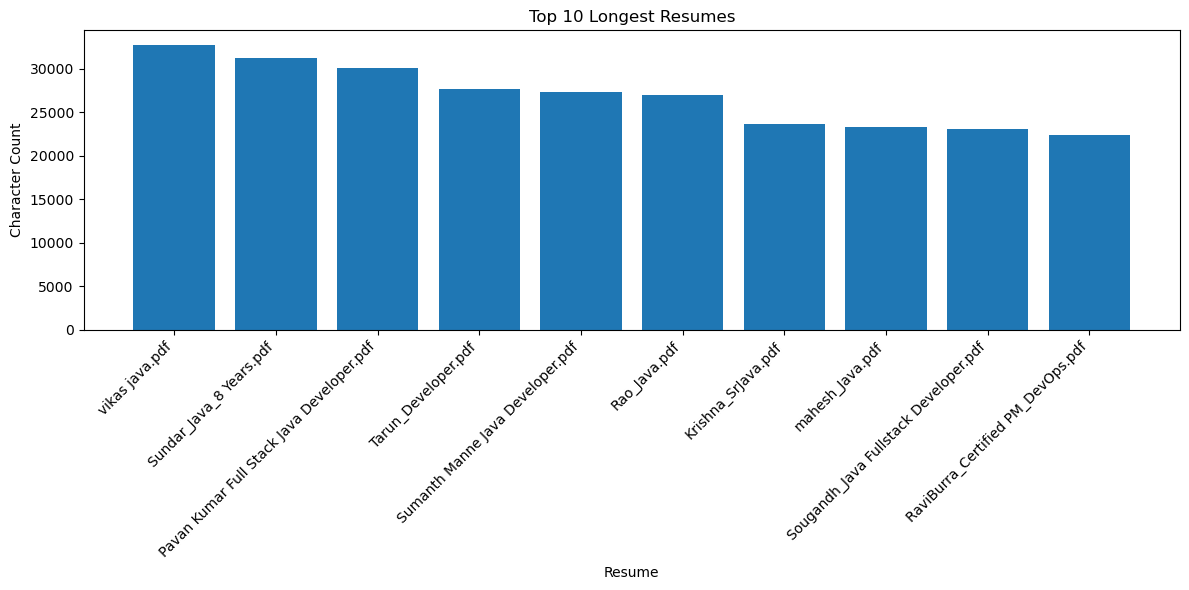

In [71]:
#visualisation
resume_df["text_length"] = resume_df["resume_text"].apply(len)

top_10 = resume_df.sort_values(
    by="text_length",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

plt.bar(
    top_10["resume_name"],
    top_10["text_length"]
)

plt.xticks(rotation=45, ha='right')

plt.title("Top 10 Longest Resumes")
plt.xlabel("Resume")
plt.ylabel("Character Count")

plt.tight_layout()
plt.show()

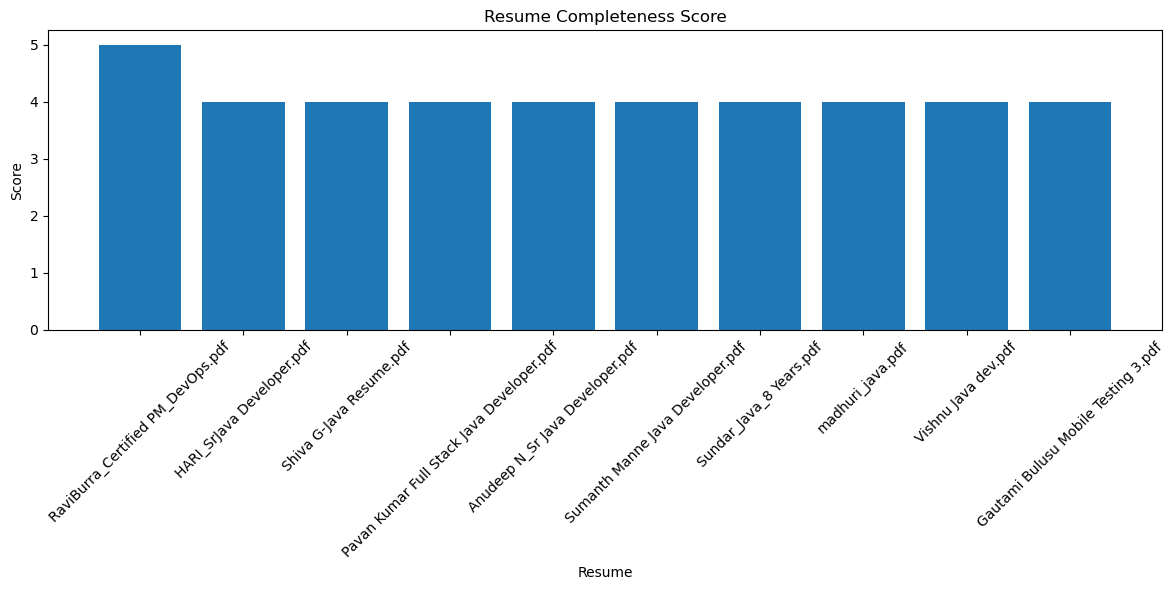

In [72]:
#trial work 
sections = [
    "skills",
    "education",
    "experience",
    "projects",
    "certifications"
]

def calculate_completeness(text):

    text = str(text).lower()

    score = 0

    for section in sections:

        if section in text:
            score += 1

    return score

resume_df["completeness_score"] = resume_df["resume_text"].apply(
    calculate_completeness
)

resume_df[[
    "resume_name",
    "completeness_score"
]].head()

# visualization
top_resumes = resume_df.sort_values(
    by="completeness_score",
    ascending=False
)

plt.figure(figsize=(12,6))

plt.bar(
    top_resumes["resume_name"][:10],
    top_resumes["completeness_score"][:10]
)

plt.xticks(rotation=45)

plt.title("Resume Completeness Score")

plt.xlabel("Resume")

plt.ylabel("Score")

plt.tight_layout()

plt.show()

In [73]:
# data frame to csv
resume_df.to_csv(
    r"D:\AI_ATS_Resume_Screening_System\resume\test\csv\resume_data.csv",
    index=False
)

print("Resume data saved successfully!")

Resume data saved successfully!


In [74]:
# to check 
import os

csv_path = r"D:\AI_ATS_Resume_Screening_System\resume\test\csv"

print(os.listdir(csv_path))

['candidate_ranking.csv', 'clean_resume_data.csv', 'dashboard_data.csv', 'final_ats_results.csv', 'resume_data.csv', 'skills_data.csv']
